In [2]:
import pandas as pd

## *Data Cleaning on Transactions*

In [3]:
transaction_df = pd.read_excel('QVI_transaction_data.xlsx')

transaction_df.head()

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES
0,43390,1,1000,1,5,Natural Chip Compny SeaSalt175g,2,6.0
1,43599,1,1307,348,66,CCs Nacho Cheese 175g,3,6.3
2,43605,1,1343,383,61,Smiths Crinkle Cut Chips Chicken 170g,2,2.9
3,43329,2,2373,974,69,Smiths Chip Thinly S/Cream&Onion 175g,5,15.0
4,43330,2,2426,1038,108,Kettle Tortilla ChpsHny&Jlpno Chili 150g,3,13.8


In [5]:
transaction_df.shape

(264836, 8)

In [6]:
transaction_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 264836 entries, 0 to 264835
Data columns (total 8 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   DATE            264836 non-null  int64  
 1   STORE_NBR       264836 non-null  int64  
 2   LYLTY_CARD_NBR  264836 non-null  int64  
 3   TXN_ID          264836 non-null  int64  
 4   PROD_NBR        264836 non-null  int64  
 5   PROD_NAME       264836 non-null  object 
 6   PROD_QTY        264836 non-null  int64  
 7   TOT_SALES       264836 non-null  float64
dtypes: float64(1), int64(6), object(1)
memory usage: 16.2+ MB


In [9]:
transaction_df.isnull().sum()

DATE              0
STORE_NBR         0
LYLTY_CARD_NBR    0
TXN_ID            0
PROD_NBR          0
PROD_NAME         0
PROD_QTY          0
TOT_SALES         0
dtype: int64

In [10]:
duplicates = transaction_df.duplicated().sum()
print(f"Number of duplicate rows: {duplicates}")

Number of duplicate rows: 1


In [20]:
transaction_df = transaction_df.drop_duplicates()

print(f"Shape after removing duplicates : {transaction_df.shape}")

Shape after removing duplicates : (264835, 8)


In [ ]:
negative_qty = (transaction_df['PROD_QTY'] <= 0).sum()
negative_sales = (transaction_df['TOT_SALES'] <= 0).sum()
print(f"Negative or zero PROD_QTY: {negative_qty}")
print(f"Negative or zero TOT_SALES: {negative_sales}")

Negative or zero PROD_QTY: 0
Negative or zero TOT_SALES: 0


In [12]:
transaction_df[['PROD_QTY', 'TOT_SALES']].describe()

,PROD_QTY,TOT_SALES
count,264836.000000,264836.000000
mean,1.907309,7.304200
std,0.643654,3.083226
min,1.000000,1.500000
25%,2.000000,5.400000
50%,2.000000,7.400000
75%,2.000000,9.200000
max,200.000000,650.000000


In [22]:
# Calculate Q1, Q3, and IQR for PROD_QTY
Q1_qty = transaction_df['PROD_QTY'].quantile(0.25)
Q3_qty = transaction_df['PROD_QTY'].quantile(0.75)
IQR_qty = Q3_qty - Q1_qty
lower_bound_qty = Q1_qty - 1.5 * IQR_qty
upper_bound_qty = Q3_qty + 1.5 * IQR_qty

# Calculate for TOT_SALES
Q1_sales = transaction_df['TOT_SALES'].quantile(0.25)
Q3_sales = transaction_df['TOT_SALES'].quantile(0.75)
IQR_sales = Q3_sales - Q1_sales
lower_bound_sales = Q1_sales - 1.5 * IQR_sales
upper_bound_sales = Q3_sales + 1.5 * IQR_sales

#Count Outliers before flitering
outliers_qty = ((transaction_df['PROD_QTY'] < lower_bound_qty) | (transaction_df['PROD_QTY'] > upper_bound_qty)).sum()
outliers_sales = ((transaction_df['TOT_SALES'] < lower_bound_sales) | (transaction_df['TOT_SALES'] > upper_bound_sales)).sum()
print(f"Outliers in PROD_QTY: {outliers_qty}")
print(f"Outliers in TOT_SALES: {outliers_sales}")

# Filter out outliers
transaction_df = transaction_df[
    (transaction_df['PROD_QTY'] >= lower_bound_qty) & (transaction_df['PROD_QTY'] <= upper_bound_qty) &
    (transaction_df['TOT_SALES'] >= lower_bound_sales) & (transaction_df['TOT_SALES'] <= upper_bound_sales)
]
print(f"Shape after removing outliers: {transaction_df.shape}")

Outliers in PROD_QTY: 0
Outliers in TOT_SALES: 0
Shape after removing outliers: (236038, 8)


In [24]:
# Convert DATE to datetime (only if not already converted)
if transaction_df['DATE'].dtype != 'datetime64[ns]':
    transaction_df['DATE'] = pd.to_datetime(transaction_df['DATE'], origin='1899-12-30', unit='D', errors='coerce')

# Check for invalid dates (NaT values)
invalid_dates = transaction_df['DATE'].isna().sum()
print(f"Invalid dates after conversion: {invalid_dates}")

# If many are invalid, inspect the original values
print(transaction_df['DATE'].head())  # Check converted dates
print(transaction_df['DATE'].min(), transaction_df['DATE'].max())  # Check date range

Invalid dates after conversion: 0
0    2018-10-17
2    2019-05-20
9    2018-08-18
12   2019-05-18
24   2018-08-15
Name: DATE, dtype: datetime64[ns]
2018-07-01 00:00:00 2019-06-30 00:00:00


In [26]:
transaction_df['DATE'].head(10)

0    2018-10-17
2    2019-05-20
9    2018-08-18
12   2019-05-18
24   2018-08-15
26   2018-08-19
32   2019-05-20
38   2018-08-18
53   2019-05-19
57   2019-05-14
Name: DATE, dtype: datetime64[ns]

Unique product names: 114


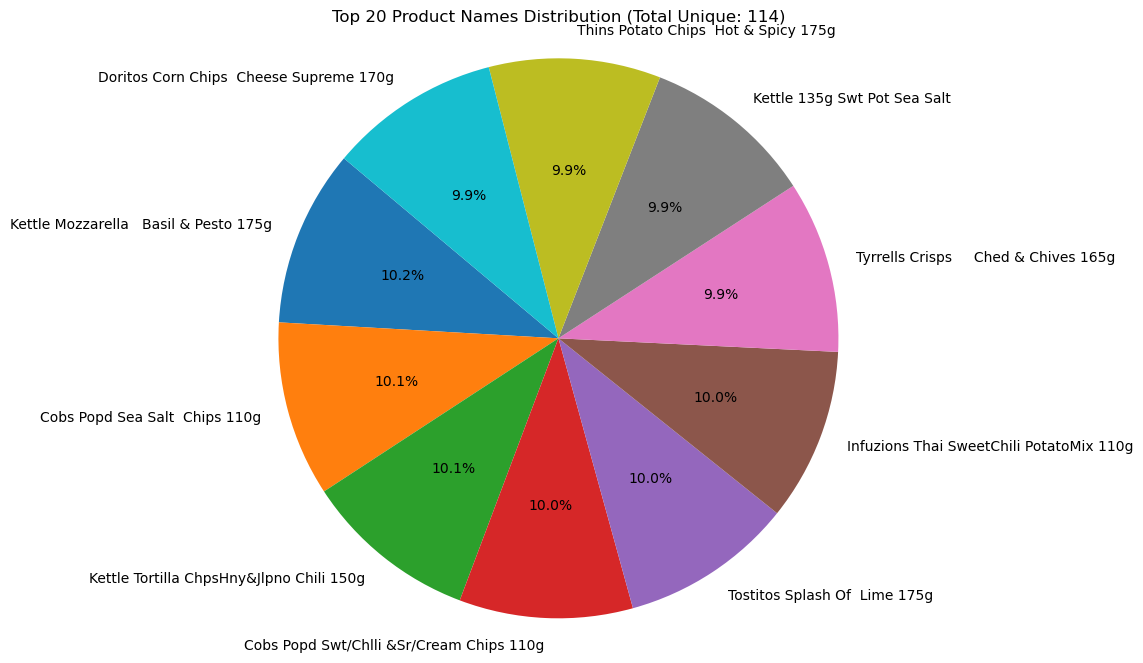

In [30]:
import matplotlib.pyplot as plt
unique_prod_names = transaction_df['PROD_NAME'].nunique()
print(f"Unique product names: {unique_prod_names}")
# Inspect a sample for irregularities
top_20_prod = transaction_df['PROD_NAME'].value_counts().head(10)

#Create a pie chart for this visualization
plt.figure(figsize=(10,8))
plt.pie(top_20_prod.values, labels=top_20_prod.index, autopct='%1.1f%%', startangle=140)
plt.title(f'Top 20 Product Names Distribution (Total Unique: {unique_prod_names})')
plt.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.
plt.show()


## *Data Cleaning on Customers*

In [1]:
import pandas as pd

customers_df = pd.read_csv('QVI_purchase_behaviour.csv')

customers_df.head()

,LYLTY_CARD_NBR,LIFESTAGE,PREMIUM_CUSTOMER
0,1000,YOUNG SINGLES/COUPLES,Premium
1,1002,YOUNG SINGLES/COUPLES,Mainstream
2,1003,YOUNG FAMILIES,Budget
3,1004,OLDER SINGLES/COUPLES,Mainstream
4,1005,MIDAGE SINGLES/COUPLES,Mainstream


In [ ]:
customers_df.shape

(72637, 3)

In [5]:
customers_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 72637 entries, 0 to 72636
Data columns (total 3 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   LYLTY_CARD_NBR    72637 non-null  int64 
 1   LIFESTAGE         72637 non-null  object
 2   PREMIUM_CUSTOMER  72637 non-null  object
dtypes: int64(1), object(2)
memory usage: 1.7+ MB


In [4]:
customers_df.isnull().sum()

LYLTY_CARD_NBR      0
LIFESTAGE           0
PREMIUM_CUSTOMER    0
dtype: int64

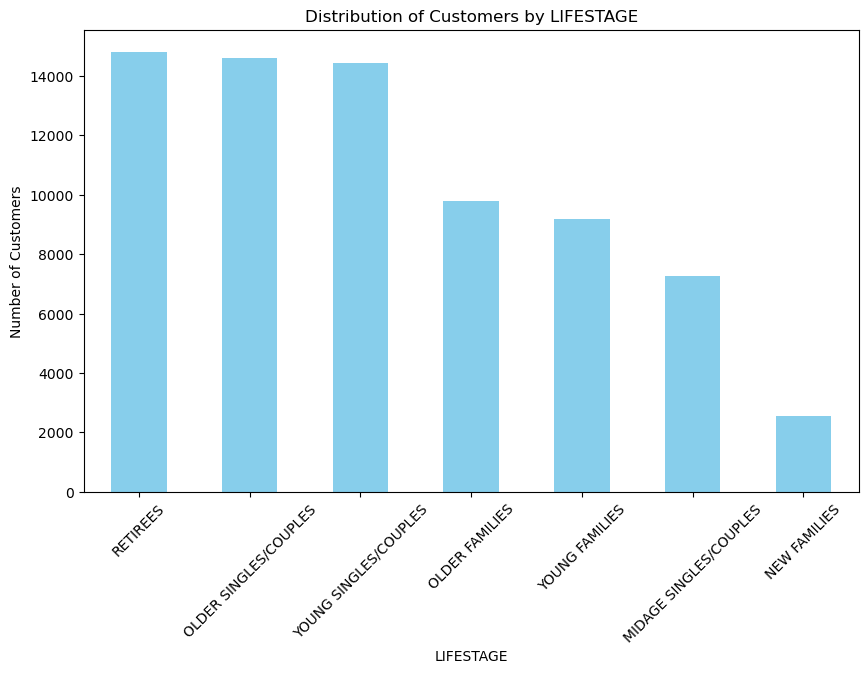

In [6]:
import matplotlib.pyplot as plt

lifestage_count = customers_df['LIFESTAGE'].value_counts()

plt.figure(figsize=(10,6))
lifestage_count.plot(kind='bar', color = 'skyblue')
plt.title('Distribution of Customers by LIFESTAGE')
plt.xlabel('LIFESTAGE')
plt.ylabel('Number of Customers')
plt.xticks(rotation = 45)
plt.show()


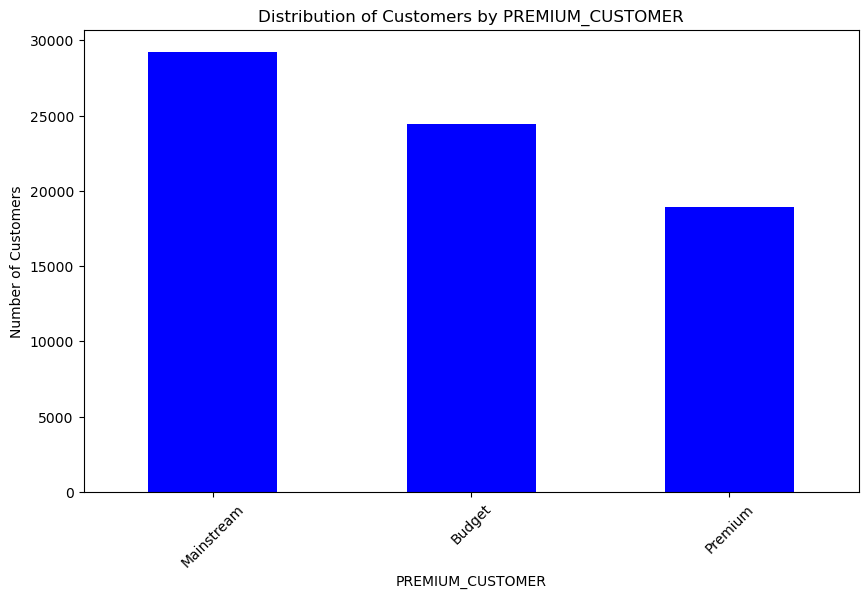

In [9]:
import matplotlib.pyplot as plt

premium_customers_count = customers_df['PREMIUM_CUSTOMER'].value_counts()

plt.figure(figsize=(10,6))
premium_customers_count.plot(kind = 'bar',color = 'blue')
plt.title('Distribution of Customers by PREMIUM_CUSTOMER')
plt.xlabel('PREMIUM_CUSTOMER')
plt.ylabel('Number of Customers')
plt.xticks(rotation = 45)
plt.show()


## *Data Merging*

In [12]:
customers_df = pd.read_csv('QVI_purchase_behaviour.csv')
transaction_df = pd.read_excel('QVI_transaction_data.xlsx')

In [29]:
# In the "Data Merging" section, after reloading:
customers_df = pd.read_csv('QVI_purchase_behaviour.csv')
transaction_df = pd.read_excel('QVI_transaction_data.xlsx')

# Add this: Convert DATE if not already datetime
if transaction_df['DATE'].dtype != 'datetime64[ns]':
    transaction_df['DATE'] = pd.to_datetime(transaction_df['DATE'], origin='1899-12-30', unit='D', errors='coerce')

merged_df = pd.merge(transaction_df, customers_df, on ='LYLTY_CARD_NBR', how = 'left')

merged_df = merged_df.drop_duplicates()

#validate the merge dataset
print("Merge Dataframe shape: ", merged_df.shape)
print("Checking any null values in merged dataframe")
print(merged_df.isnull().sum())

#Making sure if there is no duplicates in merged dataframe
duplicates = merged_df.duplicated().sum()
print(f'Number of duplicates rows in merged Dataframe: {duplicates}')


# check for the unmatched records (Rows where customer data is missing)
unmatched = merged_df['LIFESTAGE'].isnull().sum()
print(f'Number of unmatched records by checking if there is a missing customer data : {unmatched}')

# Save the merged dataset
merged_df.to_csv('merged_data.csv', index=False)
print("Merged dataset saved as 'merged_data.csv'")

Merge Dataframe shape:  (264835, 10)
Checking any null values in merged dataframe
DATE                0
STORE_NBR           0
LYLTY_CARD_NBR      0
TXN_ID              0
PROD_NBR            0
PROD_NAME           0
PROD_QTY            0
TOT_SALES           0
LIFESTAGE           0
PREMIUM_CUSTOMER    0
dtype: int64
Number of duplicates rows in merged Dataframe: 0
Number of unmatched records by checking if there is a missing customer data : 0
Merged dataset saved as 'merged_data.csv'


In [30]:
merged_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 264835 entries, 0 to 264835
Data columns (total 10 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   DATE              264835 non-null  datetime64[ns]
 1   STORE_NBR         264835 non-null  int64         
 2   LYLTY_CARD_NBR    264835 non-null  int64         
 3   TXN_ID            264835 non-null  int64         
 4   PROD_NBR          264835 non-null  int64         
 5   PROD_NAME         264835 non-null  object        
 6   PROD_QTY          264835 non-null  int64         
 7   TOT_SALES         264835 non-null  float64       
 8   LIFESTAGE         264835 non-null  object        
 9   PREMIUM_CUSTOMER  264835 non-null  object        
dtypes: datetime64[ns](1), float64(1), int64(5), object(3)
memory usage: 22.2+ MB


In [31]:
merged_df.head()

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES,LIFESTAGE,PREMIUM_CUSTOMER
0,2018-10-17,1,1000,1,5,Natural Chip Compny SeaSalt175g,2,6.0,YOUNG SINGLES/COUPLES,Premium
1,2019-05-14,1,1307,348,66,CCs Nacho Cheese 175g,3,6.3,MIDAGE SINGLES/COUPLES,Budget
2,2019-05-20,1,1343,383,61,Smiths Crinkle Cut Chips Chicken 170g,2,2.9,MIDAGE SINGLES/COUPLES,Budget
3,2018-08-17,2,2373,974,69,Smiths Chip Thinly S/Cream&Onion 175g,5,15.0,MIDAGE SINGLES/COUPLES,Budget
4,2018-08-18,2,2426,1038,108,Kettle Tortilla ChpsHny&Jlpno Chili 150g,3,13.8,MIDAGE SINGLES/COUPLES,Budget


## *Descriptive Analysis on Chips Dataset*

In [34]:
import pandas as pd

merged_df = pd.read_csv('merged_data.csv')

# # Verify the loaded data
# print("Loaded merged DataFrame shape:", merged_df.shape)
# print("Null values in loaded DataFrame:")
# print(merged_df.isnull().sum())



In [35]:
#1. Total sales

total_sales_overall = merged_df['TOT_SALES'].sum()
print(f"Total Sales Overall: {total_sales_overall}")
# 1.1 store
total_sales_by_store = merged_df.groupby('STORE_NBR')['TOT_SALES'].sum()
print("Total Sales by STORE_NBR")
print(total_sales_by_store.head())

#1.2 products
total_sales_by_prod = merged_df.groupby('PROD_NAME')['TOT_SALES'].sum()
print("Total Sales by PROD_NAME:")
print(total_sales_by_prod.head())

# lifestages of customers
total_sales_by_lifestage = merged_df.groupby('LIFESTAGE')['TOT_SALES'].sum()
print("Total Sales by LIFESTAGE:")
print(total_sales_by_lifestage)

# premimum customers
total_sales_by_premium = merged_df.groupby('PREMIUM_CUSTOMER')['TOT_SALES'].sum()
print("Total Sales by PREMIUM_CUSTOMER:")
print(total_sales_by_premium)

#2 total transactions
total_transactions = merged_df['TXN_ID'].nunique()
print(f"Total Transactions : {total_transactions}")

#3 Units sold
units_sold = merged_df['PROD_QTY'].sum()
print(f"Units sold : {units_sold}")

# 4. Average Transaction Value (ATV)
avg_transaction_value = total_sales_overall / total_transactions
print(f"Average Transaction Value (ATV): {avg_transaction_value}")

# 5. Average Spend per Product per Customer Segment
avg_spend_per_segment = merged_df.groupby(['LIFESTAGE', 'PREMIUM_CUSTOMER'])['TOT_SALES'].mean().unstack()
print("Average Spend per Customer Segment:")
print(avg_spend_per_segment)

# 6. Average Quantity Purchases per Transaction
avg_qty_per_transaction = merged_df.groupby(['LIFESTAGE', 'PREMIUM_CUSTOMER'])['PROD_QTY'].mean().unstack()
print("Average Quantity Purchases per Transaction by Segment:")
print(avg_qty_per_transaction)

# Optional: Average Quantity by Store
avg_qty_by_store = merged_df.groupby('STORE_NBR')['PROD_QTY'].mean()
print("Average Quantity Purchases per Transaction by STORE_NBR:")
print(avg_qty_by_store.head())


Total Sales Overall: 1934408.9999999998
Total Sales by STORE_NBR
STORE_NBR
1     2393.60
2     2005.80
3    12802.45
4    14647.65
5     9500.80
Name: TOT_SALES, dtype: float64
Total Sales by PROD_NAME:
PROD_NAME
Burger Rings 220g                 6831.0
CCs Nacho Cheese    175g          5961.9
CCs Original 175g                 6048.0
CCs Tasty Cheese    175g          6069.0
Cheetos Chs & Bacon Balls 190g    9243.3
Name: TOT_SALES, dtype: float64
Total Sales by LIFESTAGE:
LIFESTAGE
MIDAGE SINGLES/COUPLES    184751.30
NEW FAMILIES               50433.45
OLDER FAMILIES            353767.20
OLDER SINGLES/COUPLES     402420.75
RETIREES                  366470.90
YOUNG FAMILIES            316160.10
YOUNG SINGLES/COUPLES     260405.30
Name: TOT_SALES, dtype: float64
Total Sales by PREMIUM_CUSTOMER:
PREMIUM_CUSTOMER
Budget        676211.55
Mainstream    750744.50
Premium       507452.95
Name: TOT_SALES, dtype: float64
Total Transactions : 263127
Units sold : 505122
Average Transaction Value (A

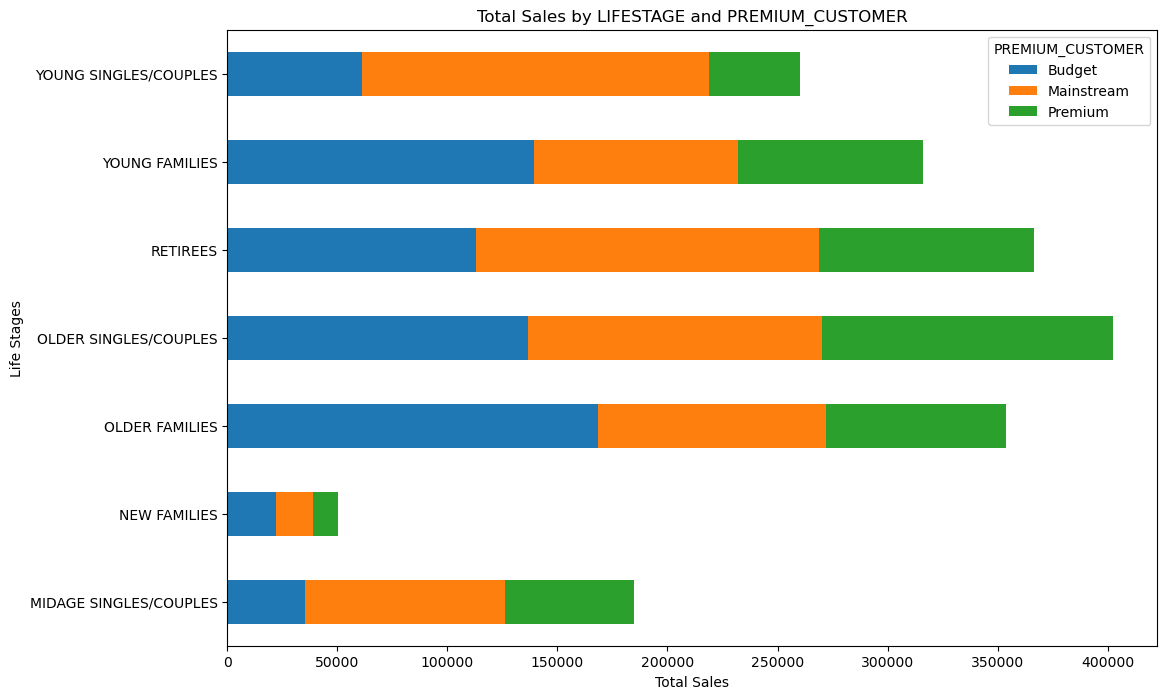

In [36]:
import matplotlib.pyplot as plt

import seaborn as sns

# Load the merged data if not already loaded
merged_df = pd.read_csv('merged_data.csv')

# Ensure DATE is datetime
merged_df['DATE'] = pd.to_datetime(merged_df['DATE'])

# 1. Bar Chart: Total Sales by LIFESTAGE and PREMIUM_CUSTOMER
sales_by_segment = merged_df.groupby(['LIFESTAGE', 'PREMIUM_CUSTOMER'])['TOT_SALES'].sum().unstack()
sales_by_segment.plot(kind='barh', figsize=(12, 8), stacked=True)
plt.title('Total Sales by LIFESTAGE and PREMIUM_CUSTOMER')
plt.xlabel('Total Sales')
plt.ylabel('Life Stages')
plt.legend(title='PREMIUM_CUSTOMER')
plt.show()



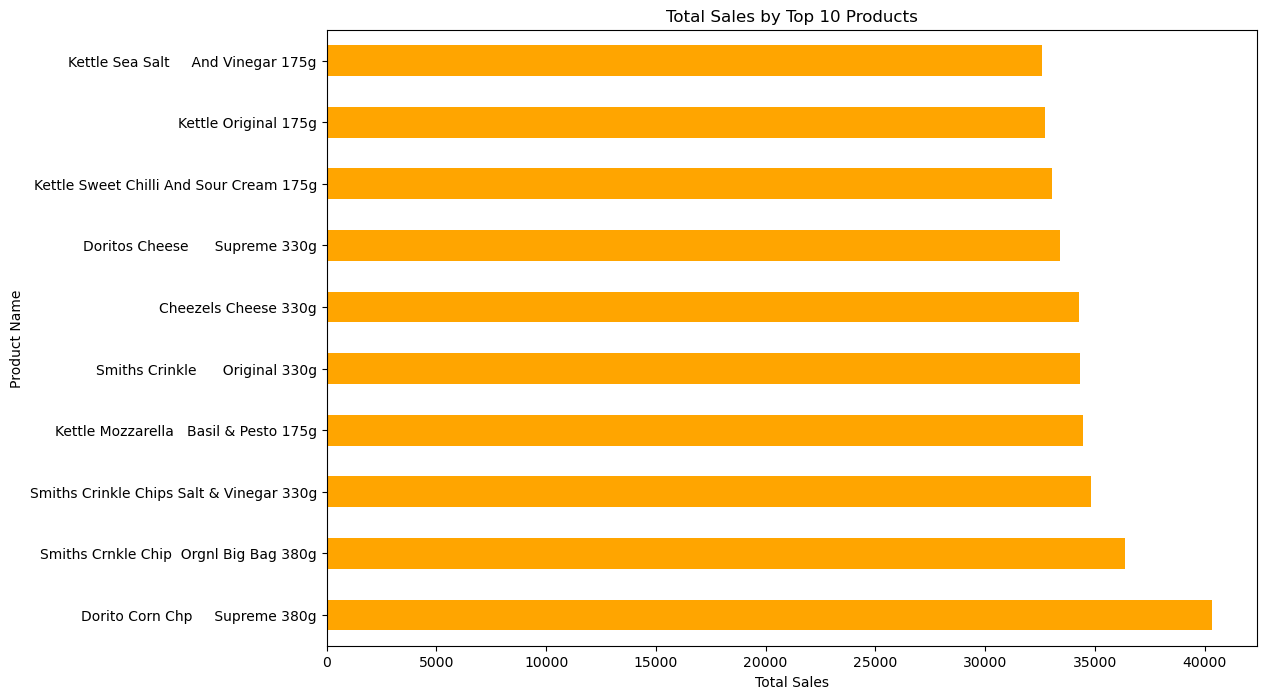

In [37]:
# 2. Bar Chart: Total Sales by Top 10 PROD_NAME
top_10_prod = merged_df.groupby('PROD_NAME')['TOT_SALES'].sum().nlargest(10)
top_10_prod.plot(kind='barh', figsize=(12, 8), color='orange')
plt.title('Total Sales by Top 10 Products')
plt.xlabel('Total Sales')  # Now on x-axis
plt.ylabel('Product Name')
plt.show()

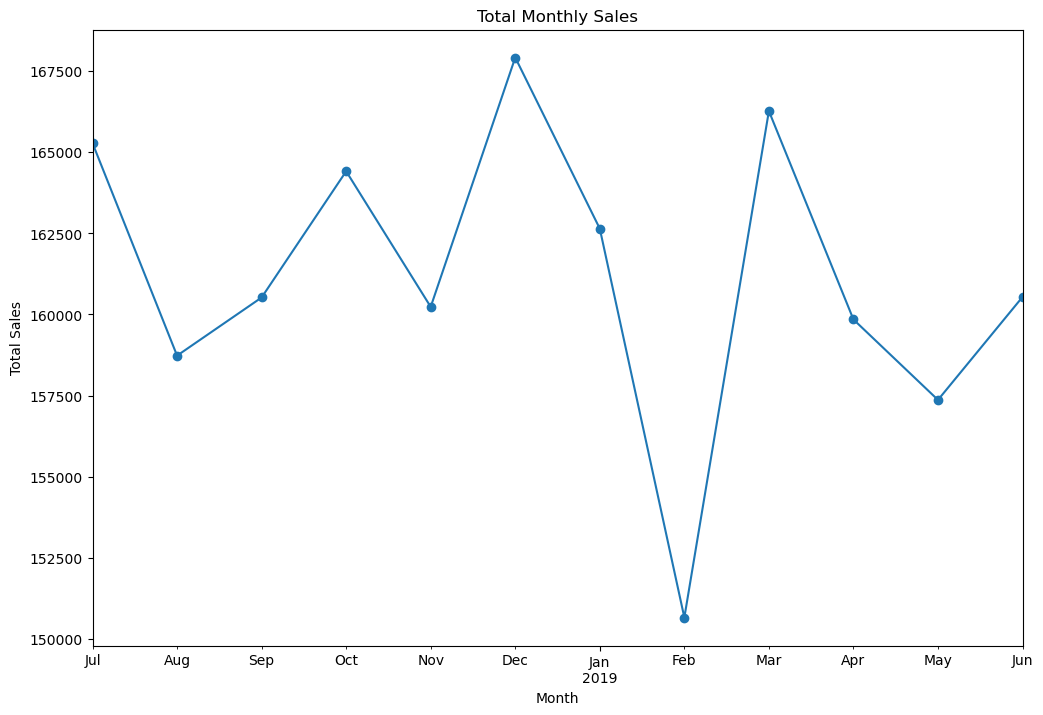

In [38]:
# 3. Line Chart: Total Monthly Sales
monthly_sales = merged_df.groupby(merged_df['DATE'].dt.to_period('M'))['TOT_SALES'].sum()
monthly_sales.index = monthly_sales.index.to_timestamp()
monthly_sales.plot(kind='line', figsize=(12, 8), marker='o')
plt.title('Total Monthly Sales')
plt.xlabel('Month')
plt.ylabel('Total Sales')
plt.show()

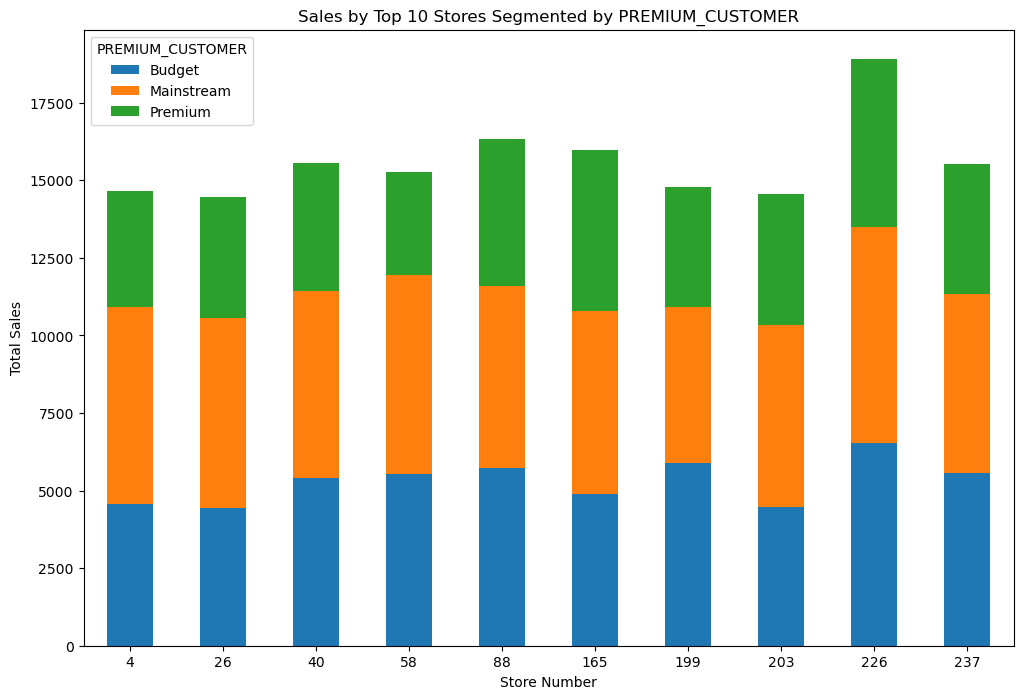

In [39]:

# 4. Stacked Bar Chart: Sales by STORE_NBR Segmented by PREMIUM_CUSTOMER (Top 10 Stores)
top_10_stores = merged_df.groupby('STORE_NBR')['TOT_SALES'].sum().nlargest(10).index
store_segment_sales = merged_df[merged_df['STORE_NBR'].isin(top_10_stores)].groupby(['STORE_NBR', 'PREMIUM_CUSTOMER'])['TOT_SALES'].sum().unstack()
store_segment_sales.plot(kind='bar', figsize=(12, 8), stacked=True)
plt.title('Sales by Top 10 Stores Segmented by PREMIUM_CUSTOMER')
plt.xlabel('Store Number')
plt.ylabel('Total Sales')
plt.xticks(rotation=0)
plt.legend(title='PREMIUM_CUSTOMER')
plt.show()

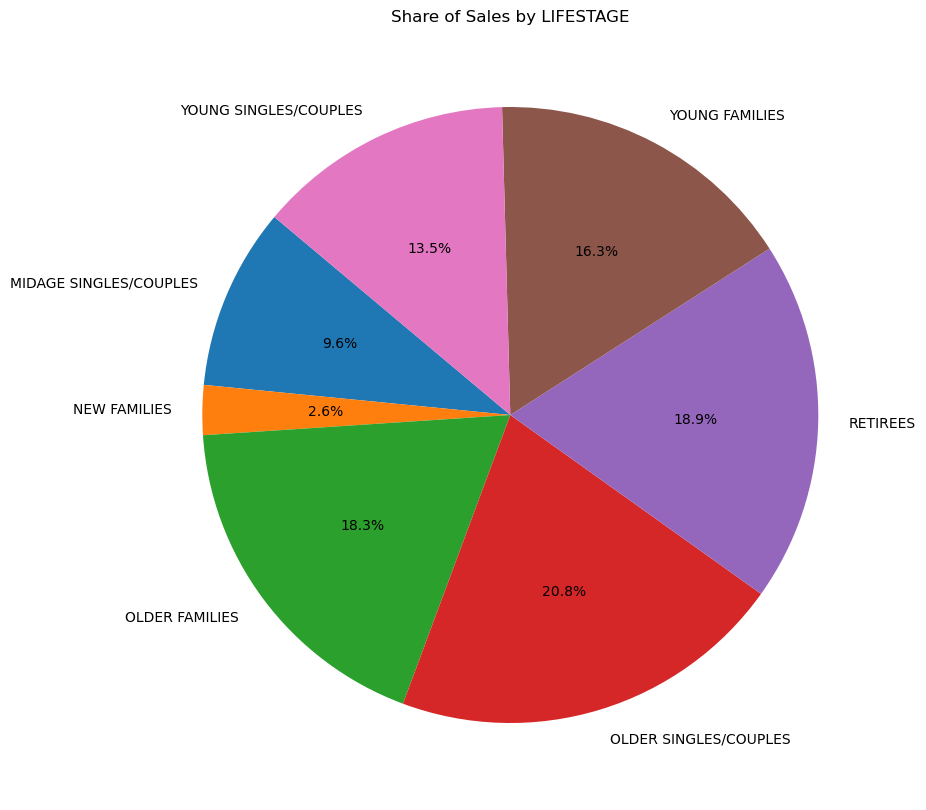

In [40]:
# 5. Pie Chart: Share of Sales by LIFESTAGE
lifestage_sales = merged_df.groupby('LIFESTAGE')['TOT_SALES'].sum()
lifestage_sales.plot(kind='pie', figsize=(10, 10), autopct='%1.1f%%', startangle=140)
plt.title('Share of Sales by LIFESTAGE')
plt.ylabel('')
plt.show()

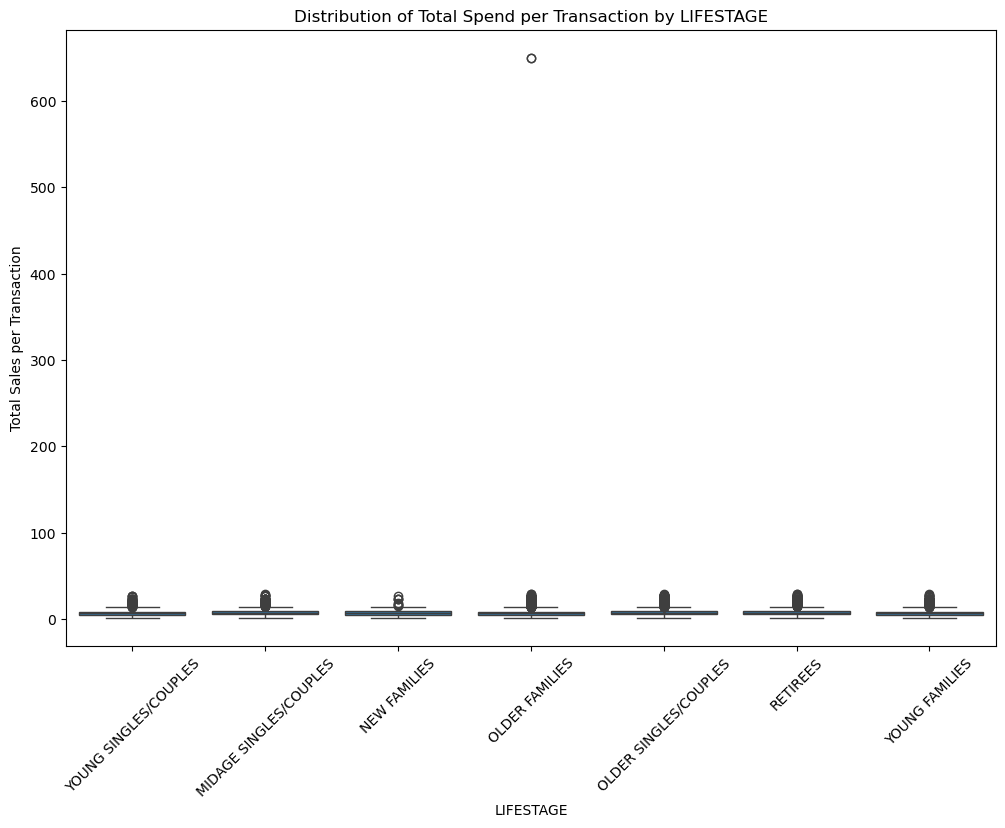

In [41]:
# 6. Box Plot: Distribution of Total Spend per Transaction by LIFESTAGE
plt.figure(figsize=(12, 8))
sns.boxplot(data=merged_df, x='LIFESTAGE', y='TOT_SALES')
plt.title('Distribution of Total Spend per Transaction by LIFESTAGE')
plt.xlabel('LIFESTAGE')
plt.ylabel('Total Sales per Transaction')
plt.xticks(rotation=45)
plt.show()